In [2]:
library(dplyr)
library(readr)
library(stats)
# Загрузка данных
df <- read_csv("mxmh_survey_results.csv")
head(df)

# Заполнение NA в указанных числовых колонках средними значениями
cols_to_fill <- c("Age", "Hours per day", "BPM", "Anxiety", "Depression", "Insomnia", "OCD")
df <- df %>%
  mutate(across(all_of(cols_to_fill), ~ ifelse(is.na(.), mean(., na.rm = TRUE), .)))

# Создание датафрейма с факторами и целевой переменной
X_df <- df %>%
  select(`Fav genre`, `Hours per day`, Age, OCD) %>%
  mutate(`Fav genre` = factor(`Fav genre`)) %>%
  na.omit()  # Удаление строк с NA

# Линейная регрессия с statsmodels (аналог)
model <- lm(OCD ~ `Fav genre` + `Hours per day` + Age, data = X_df)
summary(model)

# Вычисление метрик
predictions <- predict(model, X_df)
residuals <- X_df$OCD - predictions
mse <- mean(residuals^2)
r2 <- summary(model)$r.squared
print(paste("R^2:", round(r2, 4)))
print(paste("MSE:", round(mse, 4)))


Присоединяю пакет: 'dplyr'


Следующие объекты скрыты от 'package:stats':

    filter, lag


Следующие объекты скрыты от 'package:base':

    intersect, setdiff, setequal, union


Rows: 736 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (26): Timestamp, Primary streaming service, While working, Instrumentali...
dbl  (7): Age, Hours per day, BPM, Anxiety, Depression, Insomnia, OCD

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,⋯,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
8/27/2022 19:29:02,18,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,⋯,Sometimes,Very frequently,Never,Sometimes,3,0,1,0,NA,I understand.
8/27/2022 19:57:31,63,Pandora,1.5,Yes,No,No,Rock,Yes,No,⋯,Sometimes,Rarely,Very frequently,Rarely,7,2,2,1,NA,I understand.
8/27/2022 21:28:18,18,Spotify,4.0,No,No,No,Video game music,No,Yes,⋯,Never,Rarely,Rarely,Very frequently,7,7,10,2,No effect,I understand.
8/27/2022 21:40:40,61,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,⋯,Sometimes,Never,Never,Never,9,7,3,3,Improve,I understand.
8/27/2022 21:54:47,18,Spotify,4.0,Yes,No,No,R&B,Yes,No,⋯,Very frequently,Very frequently,Never,Rarely,7,2,5,9,Improve,I understand.
8/27/2022 21:56:50,18,Spotify,5.0,Yes,Yes,Yes,Jazz,Yes,Yes,⋯,Very frequently,Very frequently,Very frequently,Never,8,8,7,7,Improve,I understand.



Call:
lm(formula = OCD ~ `Fav genre` + `Hours per day` + Age, data = X_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.1602 -2.3408 -0.7342  1.7868  7.8524 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  2.811258   0.467976   6.007    3e-09 ***
`Fav genre`Country           0.301979   0.684494   0.441  0.65922    
`Fav genre`EDM               0.326172   0.608191   0.536  0.59192    
`Fav genre`Folk             -0.226470   0.644418  -0.351  0.72537    
`Fav genre`Gospel           -1.164903   1.243923  -0.936  0.34934    
`Fav genre`Hip hop           0.150565   0.615760   0.245  0.80690    
`Fav genre`Jazz              0.134457   0.745435   0.180  0.85691    
`Fav genre`K pop            -0.174949   0.679936  -0.257  0.79702    
`Fav genre`Latin            -1.347331   1.680449  -0.802  0.42295    
`Fav genre`Lofi              0.768800   0.974012   0.789  0.43019    
`Fav genre`Metal            -0.085706   0.491

[1] "R^2: 0.0382"
[1] "MSE: 7.7576"


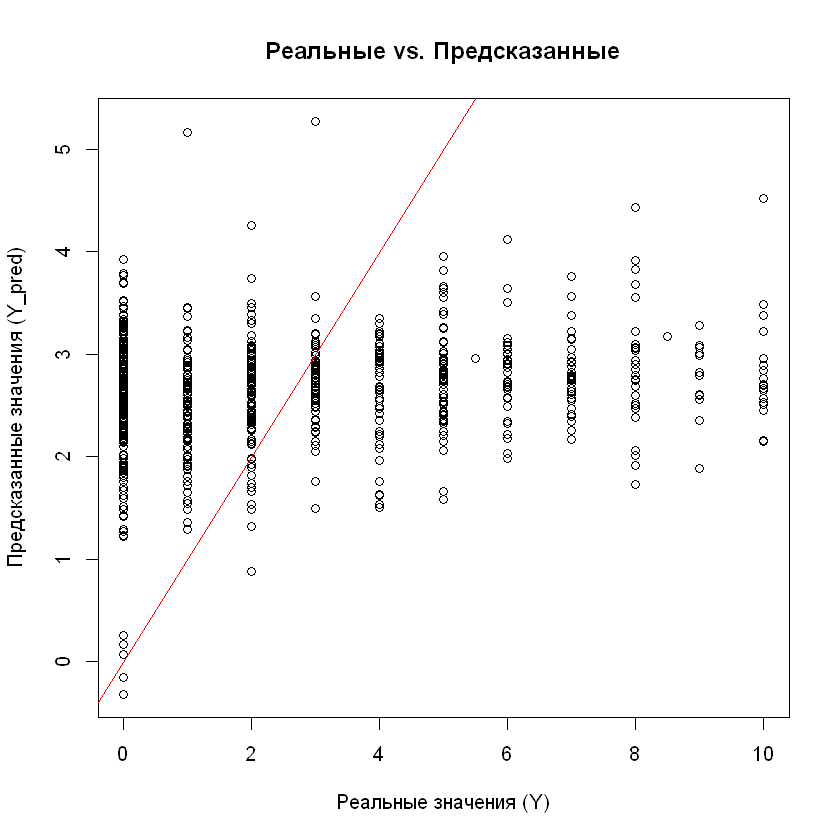

In [3]:
predictions <- predict(model, df)
plot(df$OCD, predictions,
xlab = "Реальные значения (Y)",
ylab = "Предсказанные значения (Y_pred)",
main = "Реальные vs. Предсказанные")
abline(a=0, b=1, col="red")

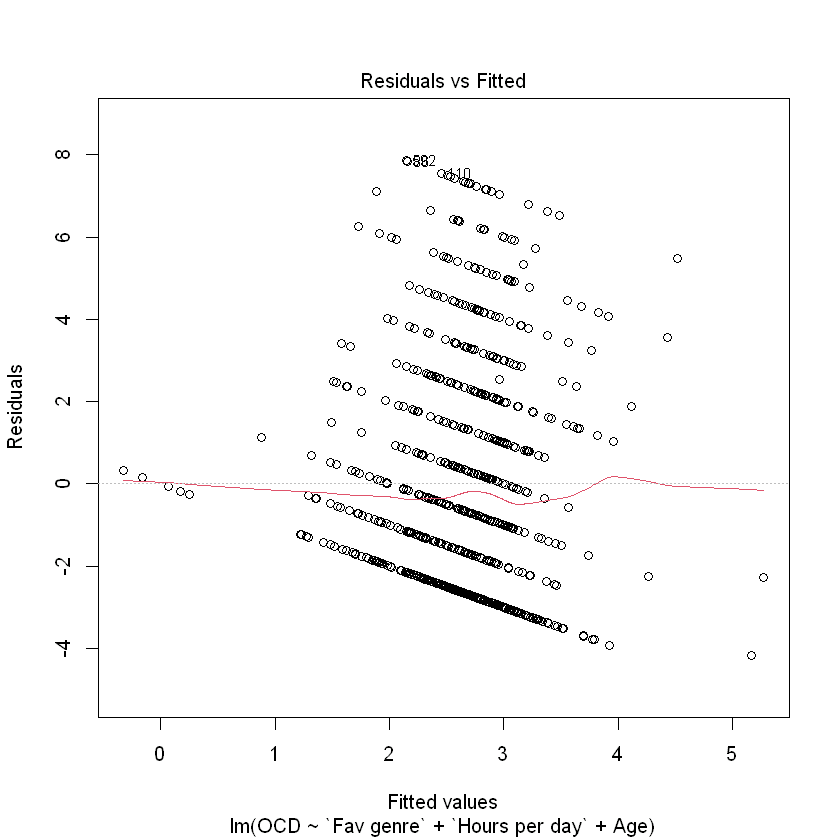

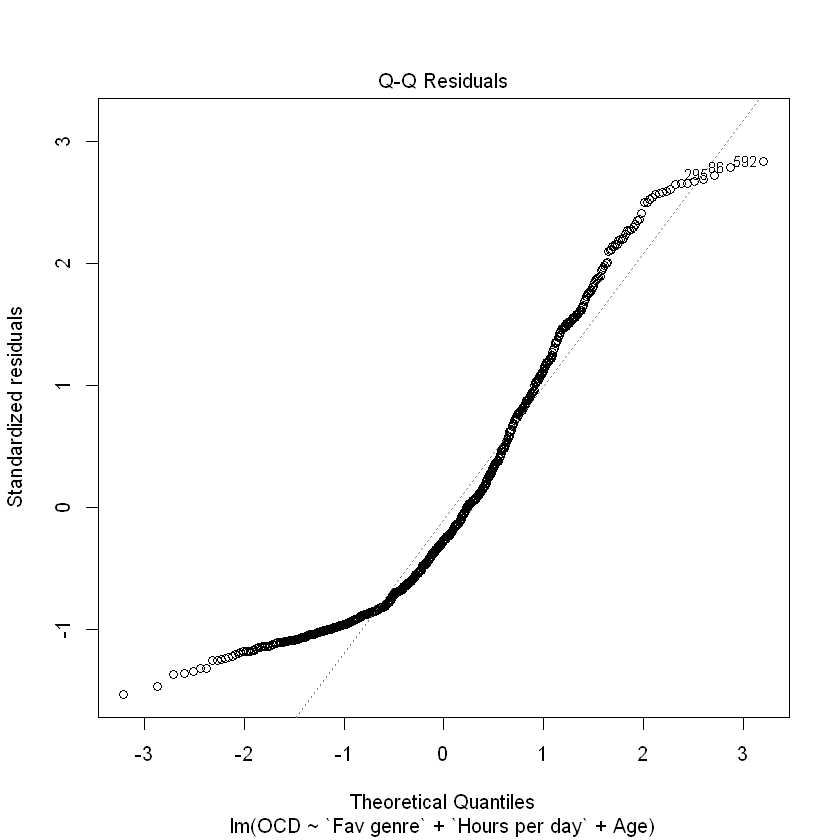

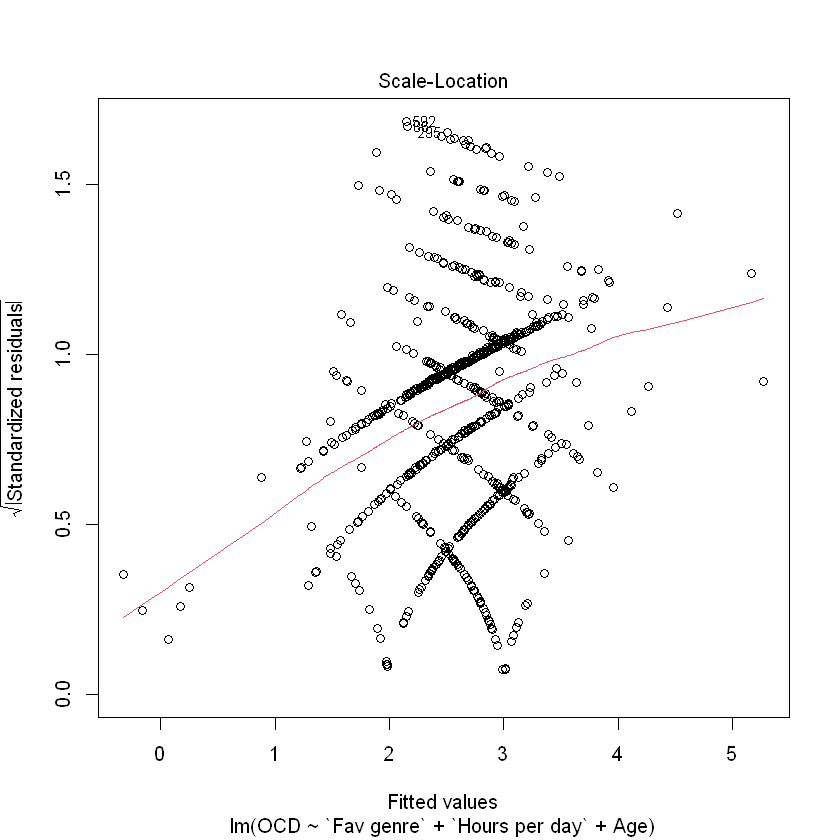

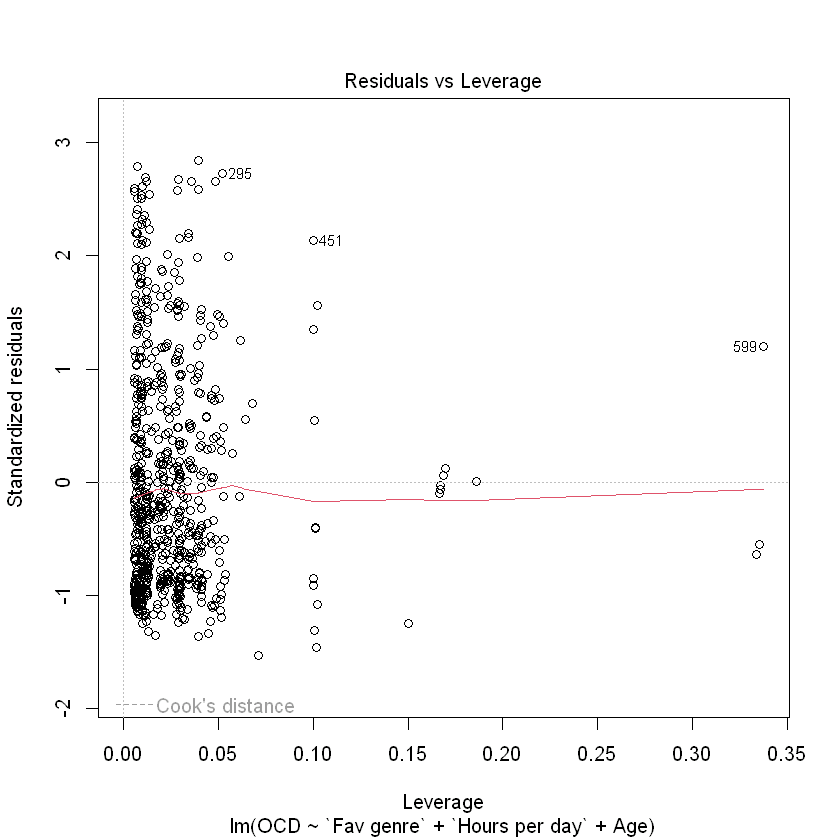

In [4]:
plot(model)